# EEG-Bench Results Analysis

This notebook analyzes benchmark results from EEG-Bench experiments.

**Features:**
- Load all experiment results from JSON files
- Data efficiency curves (accuracy vs. training data %)
- Model comparison tables and heatmaps
- BCI vs Clinical task analysis

## 1. Setup & Data Loading

In [44]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, cohen_kappa_score
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Task categorization
BCI_TASKS = ['Five Fingers MI', 'Left Hand vs Right Hand vs Feet vs Tongue MI',]
CLINICAL_TASKS = [
    "parkinsons", "schizophrenia", "mtbi", "ocd", "epilepsy",
    "abnormal", "sleep_stages", "seizure", "binary_artifact", "multiclass_artifact"
]

# Friendly names for display
TASK_DISPLAY_NAMES = {
    "left_right": "Left/Right Hand",
    "right_feet": "Right Hand/Feet",
    "left_right_feet_tongue": "4-Class MI",
    "5_fingers": "5 Fingers",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "epilepsy": "Epilepsy",
    "abnormal": "Abnormal EEG",
    "sleep_stages": "Sleep Stages",
    "seizure": "Seizure",
    "binary_artifact": "Artifact (Binary)",
    "multiclass_artifact": "Artifact (Multi)"
}

MODEL_DISPLAY_NAMES = {
    "LaBraMModel": "LaBraM",
    "BENDRModel": "BENDR",
    "NeuroGPTModel": "NeuroGPT",
    "REVEBenchmarkModel": "REVE",
    "REVEClinicalModel": "REVE",
    "LeJEPABCI": "LeJEPA",
    "LeJEPAClinical": "LeJEPA",
    "CSPLDAModel": "CSP-LDA",
    "CSPSVMModel": "CSP-SVM",
    "BrainfeaturesLDAModel": "LDA",
    "BrainfeaturesSVMModel": "SVM"
}

In [45]:

from collections.abc import Sequence


def _flatten_label_structure(values):
    """Recursively flatten nested predictions/labels regardless of depth."""
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def compute_metrics(y_true, y_pred):
    """Compute classification metrics from predictions (robust to nesting)."""
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return {
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_weighted": np.nan,
            "f1_macro": np.nan,
            "kappa": np.nan,
        }

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    metrics = {
        "accuracy": accuracy_score(y_true_arr, y_pred_arr),
        "balanced_accuracy": balanced_accuracy_score(y_true_arr, y_pred_arr),
        "f1_weighted": f1_score(y_true_arr, y_pred_arr, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true_arr, y_pred_arr),
    }
    return metrics


def _parse_eval_noise(data: dict) -> dict:
    """Parse evaluation noise metadata with backward compatibility."""
    eval_noise = data.get("eval_noise") or {}
    noise_types = eval_noise.get("noise_types")
    snr_db = eval_noise.get("snr_db")
    tag = eval_noise.get("tag")

    if not noise_types:
        noise_types = data.get("eval_noise_types") or []
    if snr_db is None:
        snr_db = data.get("eval_noise_snr_db")
    if not tag:
        tag = data.get("eval_noise_tag")

    if isinstance(noise_types, str):
        noise_types = [t for t in noise_types.replace(",", "+").split("+") if t]

    if tag is None:
        if snr_db is None or not noise_types:
            tag = "clean"
        else:
            types_str = "+".join(noise_types)
            try:
                snr_val = float(snr_db)
                snr_str = str(int(snr_val)) if snr_val.is_integer() else str(snr_val)
            except Exception:
                snr_str = str(snr_db)
            tag = f"noise_{types_str}_snr{snr_str}dB"

    is_clean = snr_db is None and not noise_types
    return {
        "noise_tag": tag,
        "noise_snr_db": snr_db,
        "noise_types": noise_types,
        "is_clean": is_clean,
    }


def load_results(results_dir="results/raw"):
    """Load all results JSON files into a DataFrame."""
    records = []

    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    print(f"Found {len(json_files)} result files")

    for filepath in json_files:
        try:
            with open(filepath) as f:
                data = json.load(f)

            task_name = data.get("task_name", "unknown")
            model_names = data.get("models_names", ["unknown"])
            percentage = data.get("data_percentage", 1.0)
            linear_probe = data.get("linear_probe", False)
            timestamp = data.get("timestamp", "")
            data_stats = data.get("data_stats", {})
            ckpt_id = data.get("checkpoint_id", {})
            step = None
            result_prefix = '' #data.get("result_prefix", "").replace('lejepa', '')
            if ckpt_id:
                step = int(ckpt_id.split('step_')[-1]) if 'last' not in ckpt_id else ckpt_id

            noise_info = _parse_eval_noise(data)

            y_test = data.get("y_test", [[]])
            results = data.get("results", [[]])

            # Process each model's results
            for i, model_name in enumerate(model_names):
                try:
                    # Get predictions for this model (handle nested structure)
                    if i < len(results):
                        y_pred = results[i] if isinstance(results[i], list) else results
                        y_true = y_test[i] if i < len(y_test) and isinstance(y_test[i], list) else y_test
                    else:
                        y_pred = results[0] if results else []
                        y_true = y_test[0] if y_test else []

                    # Compute metrics
                    metrics = compute_metrics(y_true, y_pred)

                    # Clean up model name for display
                    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

                    record = {
                        "task": task_name,
                        "task_display": TASK_DISPLAY_NAMES.get(task_name, task_name),
                        "task_type": "BCI" if task_name in BCI_TASKS else "Clinical",
                        "model": model_name + result_prefix,
                        "model_display": display_name + result_prefix,
                        "percentage": percentage,
                        "linear_probe": linear_probe,
                        "timestamp": timestamp,
                        # "total_samples": data_stats.get("total_samples", 0),
                        "file": os.path.basename(filepath),
                        "step": step,
                        **noise_info,
                        **metrics,
                    }
                    records.append(record)

                except Exception:
                    raise

        except Exception:
            raise

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} experiment results")
    return df


In [46]:

# Load results (clean + noise-aware)
df_all = load_results("results/raw")

df_clean = df_all.copy()
df_noise = df_all.iloc[0:0].copy()

if len(df_all) > 0:
    # Normalize noise types for grouping/labels
    if "noise_types" in df_all.columns:
        df_all["noise_types_str"] = df_all["noise_types"].apply(
            lambda x: "+".join(x) if isinstance(x, (list, tuple)) else ""
        )
    else:
        df_all["noise_types_str"] = ""

    df_clean = df_all[df_all["is_clean"]].copy() if "is_clean" in df_all.columns else df_all.copy()
    df_noise = df_all[~df_all["is_clean"]].copy() if "is_clean" in df_all.columns else df_all.iloc[0:0].copy()

    # IMPORTANT: all existing plots below should use clean-only results
    df = df_clean

    print(f"Clean results: {len(df_clean)} rows")
    print(f"Noise results: {len(df_noise)} rows")
    print(f"Unique tasks (clean): {df['task'].nunique()}")
    print(f"Unique models (clean): {df['model_display'].nunique()}")
    print(f"Data percentages (clean): {sorted(df['percentage'].unique())}")
    print(f"Tasks (clean): {df['task'].unique().tolist()}")
    print(f"Models (clean): {df['model_display'].unique().tolist()}")
    print(f"Steps (clean): {df['step'].unique().tolist()}")
else:
    print("No results found. Run experiments first with run_experiments.py")


Found 327 result files
Loaded 327 experiment results
Clean results: 56 rows
Noise results: 271 rows
Unique tasks (clean): 14
Unique models (clean): 1
Data percentages (clean): [0.25, 0.5, 0.75, 1.0]
Tasks (clean): ['Left Hand vs Right Hand vs Feet vs Tongue MI', 'parkinsons_clinical', 'seizure_clinical', 'Five Fingers MI', 'ocd_clinical', 'mtbi_clinical', 'sleep_stages_clinical', 'abnormal_clinical', 'Left Hand vs Right Hand MI', 'epilepsy_clinical', 'schizophrenia_clinical', 'Right Hand vs Feet MI', 'multiclass_artifact_clinical', 'binary_artifact_clinical']
Models (clean): ['LaBraM']
Steps (clean): [None]


In [47]:
# Drop duplicates (exclude unhashable list columns like noise_types)
unhashable_cols = {"noise_types"}
exclude_cols = {"timestamp", "file"} | unhashable_cols

subset_cols = [c for c in df.columns if c not in exclude_cols]
df = df.drop_duplicates(subset=subset_cols)

print(f"After deduplication: {len(df)} rows")


After deduplication: 56 rows


In [48]:
#add baseline results (WILL NEED TO KEEP UPDATING THIS AS IT COMES!)
baseline_df = None
# baseline_df = pd.read_csv('/home/spanchavati/EEG-Bench-vICMl/results/baseline_results.csv', index_col=0)

if baseline_df is not None:
    baseline_df = baseline_df[baseline_df['model_display'].str.lower().str.contains('labram')]
    df = pd.concat([df, baseline_df], ignore_index=True)
    print(f"\nAfter adding baseline results:")
    print(f"Unique tasks: {df['task'].nunique()}")
    print(f"Unique models: {df['model_display'].nunique()}")


In [49]:
baseline_df

In [50]:
# Preview data
if len(df) > 0:
    display(df.head(10))

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,file,step,noise_tag,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,noise_types_str
0,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,BCI,LaBraMModel,LaBraM,0.50,True,20260127_112831,Left Hand vs Right Hand vs Feet vs Tongue MI_L...,None,clean,NaN,[],True,0.272093,0.272787,0.242078,0.242028,0.030514,
1,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,BCI,LaBraMModel,LaBraM,0.75,True,20260127_081005,Left Hand vs Right Hand vs Feet vs Tongue MI_L...,None,clean,NaN,[],True,0.291449,0.289776,0.281462,0.280689,0.053451,
8,parkinsons_clinical,parkinsons_clinical,Clinical,LaBraMModel,LaBraM,0.75,True,20260127_081718,parkinsons_clinical_LaBraMModel_pct75_LP_20260...,None,clean,NaN,[],True,0.503268,0.476623,0.509538,0.475838,-0.045307,
12,parkinsons_clinical,parkinsons_clinical,Clinical,LaBraMModel,LaBraM,1.00,True,20260127_051452,parkinsons_clinical_LaBraMModel_LP_20260127_05...,None,clean,NaN,[],True,0.535948,0.546011,0.544994,0.529435,0.083678,
14,seizure_clinical,seizure_clinical,Clinical,LaBraMModel,LaBraM,0.75,True,20260127_091442,seizure_clinical_LaBraMModel_pct75_LP_20260127...,None,clean,NaN,[],True,0.938252,0.655992,0.965211,0.502080,0.030326,
18,seizure_clinical,seizure_clinical,Clinical,LaBraMModel,LaBraM,0.25,True,20260127_160318,seizure_clinical_LaBraMModel_pct25_LP_20260127...,None,clean,NaN,[],True,0.992498,0.556561,0.993417,0.542570,0.085368,
20,seizure_clinical,seizure_clinical,Clinical,LaBraMModel,LaBraM,0.50,True,20260127_133039,seizure_clinical_LaBraMModel_pct50_LP_20260127...,None,clean,NaN,[],True,0.960343,0.652008,0.976864,0.515269,0.045302,
23,Five Fingers MI,Five Fingers MI,BCI,LaBraMModel,LaBraM,0.50,True,20260127_113130,Five Fingers MI_LaBraMModel_pct50_LP_20260127_...,None,clean,NaN,[],True,0.186940,0.192852,0.167471,0.169027,-0.008074,
28,parkinsons_clinical,parkinsons_clinical,Clinical,LaBraMModel,LaBraM,0.50,True,20260127_123515,parkinsons_clinical_LaBraMModel_pct50_LP_20260...,None,clean,NaN,[],True,0.535948,0.534045,0.545215,0.524241,0.063292,
33,ocd_clinical,ocd_clinical,Clinical,LaBraMModel,LaBraM,0.50,True,20260127_124604,ocd_clinical_LaBraMModel_pct50_LP_20260127_124...,None,clean,NaN,[],True,0.727273,0.716667,0.722611,0.717949,0.440678,


## 2. Data Efficiency Curves

Plots showing how model performance changes with varying amounts of training data.

In [51]:
def plot_data_efficiency(df, task, metric="balanced_accuracy", figsize=(10, 6)):
    """Plot data efficiency curve for a single task."""
    task_df = df[df["task"] == task].copy()
    
    if len(task_df) == 0:
        print(f"No data for task: {task}")
        return
    
    plt.figure(figsize=figsize)
    
    models = task_df["model_display"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
        
        # Group by percentage and compute mean/std if multiple runs
        grouped = model_df.groupby("percentage")[metric].agg(["mean", "std"]).reset_index()
        
        plt.plot(grouped["percentage"] * 100, grouped["mean"],
                 marker='o', label=model, color=color, linewidth=2, markersize=8)
        
        # Add error bars if std available
        if grouped["std"].notna().any():
            plt.fill_between(grouped["percentage"] * 100,
                           grouped["mean"] - grouped["std"],
                           grouped["mean"] + grouped["std"],
                           alpha=0.2, color=color)
    
    task_display = TASK_DISPLAY_NAMES.get(task, task)
    plt.xlabel("Training Data (%)", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"Data Efficiency: {task_display}", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 105)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def plot_all_efficiency_curves(df, metric="balanced_accuracy", tasks=None):
    """Plot data efficiency curves for all tasks."""
    if tasks is None:
        tasks = df["task"].unique()
    
    for task in tasks:
        plot_data_efficiency(df, task, metric)

In [52]:
# # Plot efficiency curves for all tasks
# if len(df) > 0:
#     plot_all_efficiency_curves(df, metric="accuracy")

In [53]:
def plot_efficiency_grid(df, metric="balanced_accuracy", ncols=3):
    """Plot all efficiency curves in a grid layout."""
    tasks = df["task"].unique()
    nrows = int(np.ceil(len(tasks) / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if len(tasks) > 1 else [axes]
    
    models = df["model_display"].unique()
    colors = {m: plt.cm.tab10(i/len(models)) for i, m in enumerate(models)}
    
    for idx, task in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df["task"] == task]
        
        for model in models:
            model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
            if len(model_df) > 0:
                grouped = model_df.groupby("percentage")[metric].mean().reset_index()
                ax.plot(grouped["percentage"] * 100, grouped[metric],
                       marker='o', label=model, color=colors[model], linewidth=2)
        
        ax.set_title(TASK_DISPLAY_NAMES.get(task, task), fontsize=11)
        ax.set_xlabel("Training Data (%)")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(tasks), len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=min(5, len(models)),
              bbox_to_anchor=(0.5, 1.02), fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig("results/efficiency_curves_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/efficiency_curves_grid.png")

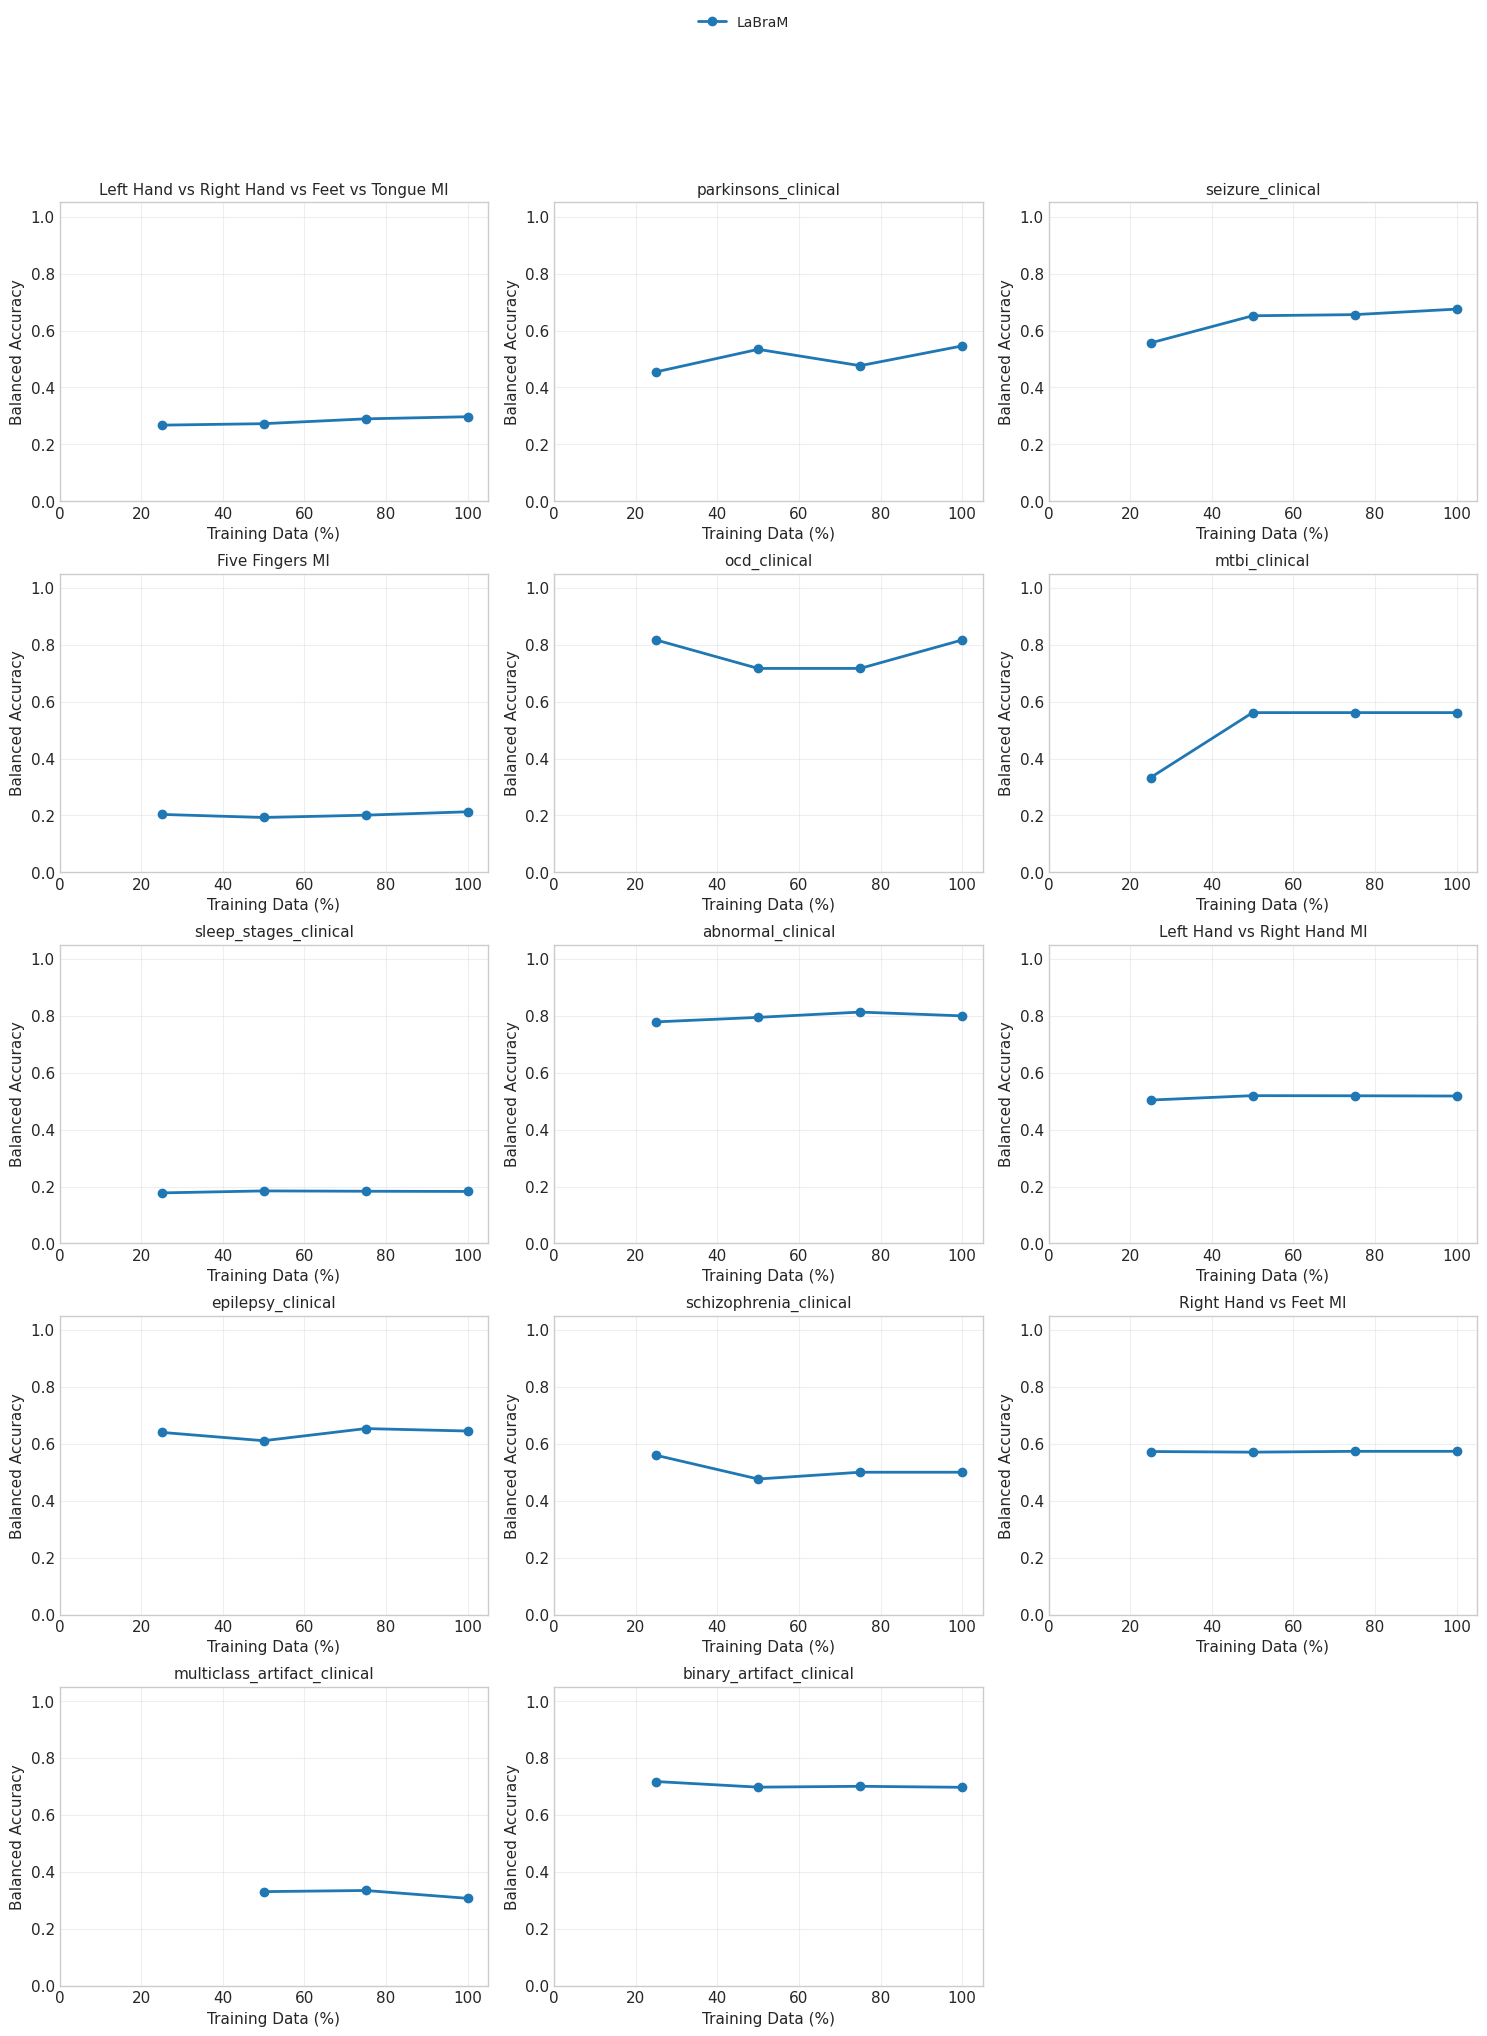

Saved to results/efficiency_curves_grid.png


In [54]:
# Plot grid view
if len(df) > 0 and df["task"].nunique() > 1:
    plot_efficiency_grid(df)

## 3. Model Comparison Tables

In [55]:
def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy"):
    """Create pivot table: models (rows) x tasks (columns)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        print(f"No data for percentage={percentage}")
        return None
    
    table = subset.pivot_table(
        values=metric,
        index="model_display",
        columns="task_display",
        aggfunc="mean"
    )
    
    # Add mean column
    table["Mean"] = table.mean(axis=1)
    
    # Sort by mean performance
    table = table.sort_values("Mean", ascending=False)
    
    return table.round(3)

In [56]:
# Display comparison table at 100% data
if len(df) > 0:
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        print("Model Comparison (100% training data, Balanced Accuracy):")
        display(table.style.background_gradient(cmap="RdYlGn", axis=None))

Model Comparison (100% training data, Balanced Accuracy):


task_display,Five Fingers MI,Left Hand vs Right Hand MI,Left Hand vs Right Hand vs Feet vs Tongue MI,Right Hand vs Feet MI,abnormal_clinical,binary_artifact_clinical,epilepsy_clinical,mtbi_clinical,multiclass_artifact_clinical,ocd_clinical,parkinsons_clinical,schizophrenia_clinical,seizure_clinical,sleep_stages_clinical,Mean
model_display,,,,,,,,,,,,,,,
LaBraM,0.213000,0.518000,0.297000,0.573000,0.800000,0.697000,0.645000,0.561000,0.307000,0.817000,0.546000,0.500000,0.675000,0.183000,0.524000


In [57]:
def plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy", figsize=(14, 6)):
    """Plot heatmap of model performance across tasks."""
    table = model_comparison_table(df, percentage, metric)
    
    if table is None or len(table) == 0:
        return
    
    # Remove Mean column for heatmap
    plot_table = table.drop(columns=["Mean"], errors="ignore")
    
    plt.figure(figsize=figsize)
    sns.heatmap(plot_table, annot=True, cmap="RdYlGn", fmt=".2f",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": metric.replace("_", " ").title()})
    plt.title(f"Model {metric.replace('_', ' ').title()} by Task ({int(percentage*100)}% training data)",
              fontsize=14)
    plt.xlabel("Task", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"results/comparison_heatmap_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to results/comparison_heatmap_{metric}.png")

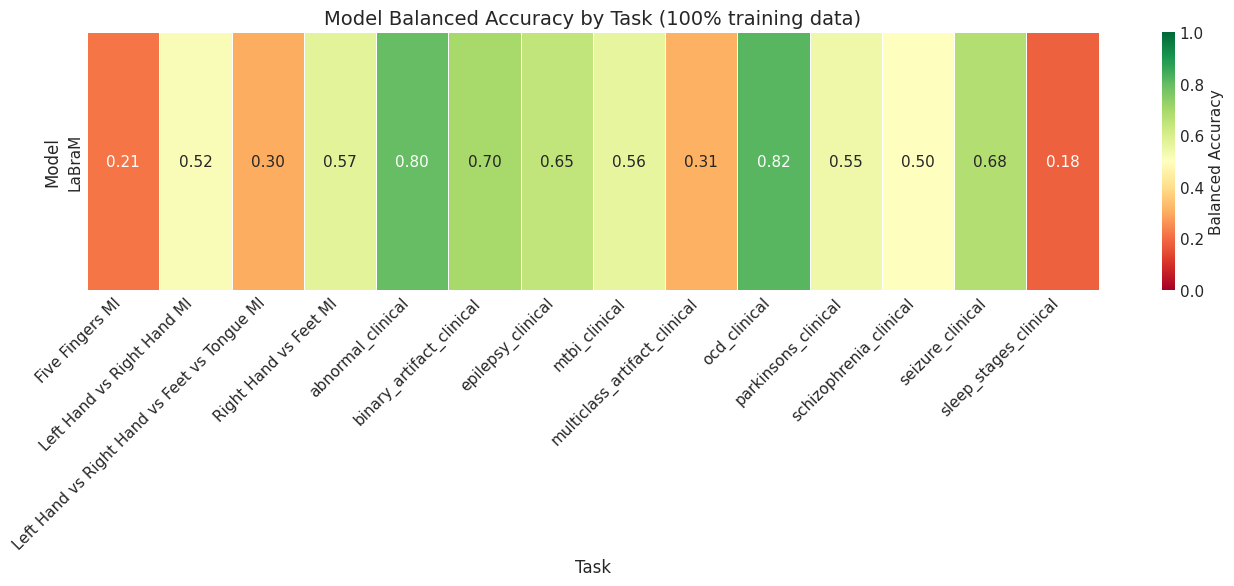

Saved to results/comparison_heatmap_balanced_accuracy.png


In [58]:
# Plot heatmap
if len(df) > 0:
    plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy")

## 4. Summary Statistics

In [59]:
def best_model_per_task(df, percentage=1.0, metric="balanced_accuracy"):
    """Find the best performing model for each task."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Group and find best
    idx = subset.groupby("task")[metric].idxmax()
    best = subset.loc[idx][["task", "task_display", "model_display", metric]].copy()
    best = best.rename(columns={metric: f"best_{metric}"})
    best = best.sort_values("task_display")
    
    return best

In [60]:
# Best model per task
if len(df) > 0:
    best = best_model_per_task(df)
    if best is not None:
        print("Best Model per Task (100% training data)")
        display(best)

Best Model per Task (100% training data)


,task,task_display,model_display,best_balanced_accuracy
170,Five Fingers MI,Five Fingers MI,LaBraM,0.212911
86,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,LaBraM,0.518028
153,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,LaBraM,0.297201
249,Right Hand vs Feet MI,Right Hand vs Feet MI,LaBraM,0.573421
217,abnormal_clinical,abnormal_clinical,LaBraM,0.799683
306,binary_artifact_clinical,binary_artifact_clinical,LaBraM,0.696736
235,epilepsy_clinical,epilepsy_clinical,LaBraM,0.644778
303,mtbi_clinical,mtbi_clinical,LaBraM,0.561404
276,multiclass_artifact_clinical,multiclass_artifact_clinical,LaBraM,0.306593
240,ocd_clinical,ocd_clinical,LaBraM,0.816667


In [61]:
# def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
#     """Compute average rank of each model across tasks."""
#     subset = df[df["percentage"] == percentage].copy()
    
#     if len(subset) == 0:
#         return None
    
#     # Compute rank per task (1 = best)
#     subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
#     # Average rank per model
#     rankings = subset.groupby("model_display").agg({
#         "rank": "mean",
#         metric: "mean"
#     }).round(2)
    
#     rankings = rankings.sort_values("rank")
#     rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
#     return rankings

def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
    """Compute average rank of each model across tasks (only tasks with 2+ models)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Only include tasks that have multiple models
    task_model_counts = subset.groupby("task")["model_display"].nunique()
    tasks_with_multiple_models = task_model_counts[task_model_counts > 1].index
    print(len(tasks_with_multiple_models))
    subset = subset[subset["task"].isin(tasks_with_multiple_models)]
    
    if len(subset) == 0:
        print("No tasks with multiple models to rank")
        return None
    
    # Compute rank per task (1 = best)
    subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
    # Average rank per model
    rankings = subset.groupby("model_display").agg({
        "rank": "mean",
        metric: "mean"
    }).round(2)
    
    rankings = rankings.sort_values("rank")
    rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
    return rankings

In [62]:
# Model rankings
if len(df) > 0:
    rankings = compute_model_rankings(df)
    if rankings is not None:
        print("Model Rankings (lower rank = better)")
        display(rankings)

0
No tasks with multiple models to rank


## 5. BCI vs Clinical Comparison

In [63]:
def plot_bci_vs_clinical(df, percentage=1.0, metric="accuracy"):
    """Compare model performance on BCI vs Clinical tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return
    
    # Group by model and task type
    comparison = subset.groupby(["model_display", "task_type"])[metric].mean().unstack()
    comparison = comparison.sort_values("BCI", ascending=False) if "BCI" in comparison.columns else comparison
    
    # Plot
    ax = comparison.plot(kind="bar", figsize=(12, 6), width=0.8)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"BCI vs Clinical Performance ({int(percentage*100)}% training data)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Task Type", fontsize=10)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/bci_vs_clinical.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/bci_vs_clinical.png")

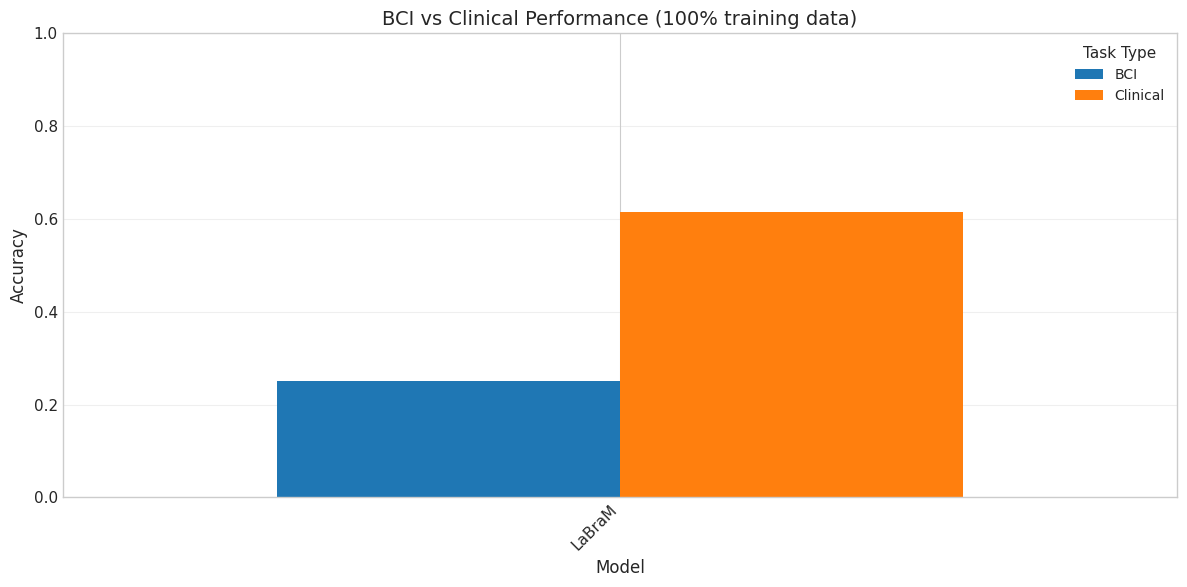

Saved to results/bci_vs_clinical.png


In [64]:
# BCI vs Clinical comparison
if len(df) > 0:
    plot_bci_vs_clinical(df)

## 6. Export Results

In [65]:
# Export full results to CSV
if len(df) > 0:
    output_path = "results/analysis_summary.csv"
    df.to_csv(output_path, index=False)
    print(f"Exported results to {output_path}")
    
    # Also export comparison table
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        table.to_csv("results/model_comparison_table.csv")
        print("Exported comparison table to results/model_comparison_table.csv")

Exported results to results/analysis_summary.csv
Exported comparison table to results/model_comparison_table.csv


## 7. Custom Analysis

Use the cells below for your own analysis.

In [66]:
# Example: Filter and analyze specific subset
# df_lejepa = df[df["model_display"] == "LeJEPA"]
# df_bci = df[df["task_type"] == "BCI"]
# df_low_data = df[df["percentage"] <= 0.1]

In [67]:
# Example: Compare linear probe vs full fine-tuning (if both available)
# if "linear_probe" in df.columns and df["linear_probe"].nunique() > 1:
#     lp_comparison = df.groupby(["model_display", "linear_probe"])["accuracy"].mean().unstack()
#     display(lp_comparison)

## Additional Experiments: Noise Robustness

All plots above use clean-only results. This section visualizes the noise sweeps.


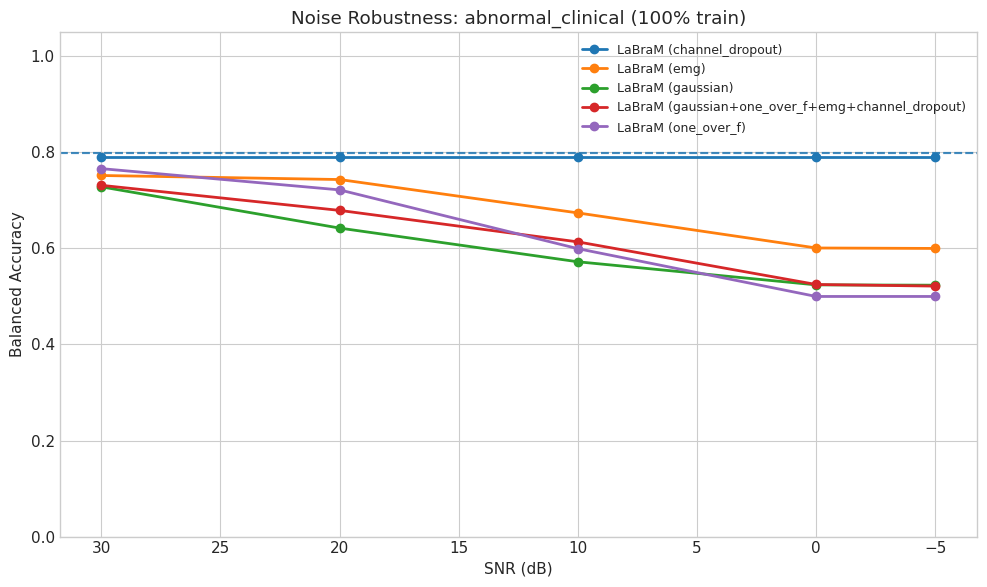

In [68]:


def plot_noise_robustness(df_all, task, metric="balanced_accuracy", percentage=1.0, figsize=(10, 6)):
    """Plot performance vs SNR for noisy evaluation runs."""
    if len(df_all) == 0 or "noise_snr_db" not in df_all.columns:
        print("No noise-aware results available.")
        return

    noisy = df_all[(df_all["task"] == task) & (~df_all["is_clean"])].copy()
    noisy = noisy[noisy["percentage"] == percentage]
    noisy = noisy.dropna(subset=["noise_snr_db"]) if "noise_snr_db" in noisy.columns else noisy

    if len(noisy) == 0:
        print(f"No noisy runs found for task={task} at percentage={percentage}.")
        return

    noisy = noisy.sort_values("noise_snr_db", ascending=False)

    # Clean baseline at the same percentage
    clean = df_all[(df_all["task"] == task) & (df_all["is_clean"]) & (df_all["percentage"] == percentage)]
    clean_baseline = clean.groupby("model_display")[metric].mean() if len(clean) > 0 else None

    plt.figure(figsize=figsize)

    group_cols = ["model_display", "noise_types_str", "noise_snr_db"]
    grouped = noisy.groupby(group_cols)[metric].mean().reset_index()

    for (model, noise_types), sub in grouped.groupby(["model_display", "noise_types_str"]):
        sub = sub.sort_values("noise_snr_db", ascending=False)
        label = model if not noise_types else f"{model} ({noise_types})"
        plt.plot(sub["noise_snr_db"], sub[metric], marker="o", linewidth=2, label=label)

        if clean_baseline is not None and model in clean_baseline.index:
            plt.axhline(clean_baseline.loc[model], linestyle="--", alpha=0.3)

    plt.xlabel("SNR (dB)")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"Noise Robustness: {TASK_DISPLAY_NAMES.get(task, task)} ({int(percentage*100)}% train)")
    plt.gca().invert_xaxis()  # Higher noise to the right visually (optional)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=9, loc="best")
    plt.tight_layout()
    plt.show()


# Example noise plot
if len(df_noise) > 0:
    plot_noise_robustness(df_all, task="abnormal_clinical", metric="balanced_accuracy", percentage=1.0)
else:
    print("No noise experiments found yet.")


In [69]:
noise_to_plot

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,file,step,noise_tag,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,noise_types_str
49,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090733,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_emg_snr30dB,30.0,[emg],False,0.616035,0.659142,0.614719,0.615967,0.280269,emg
260,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090727,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_gaussian_snr30dB,30.0,[gaussian],False,0.606016,0.653787,0.602323,0.605573,0.268330,gaussian
175,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090730,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_one_over_f_snr30dB,30.0,[one_over_f],False,0.686278,0.695442,0.691070,0.680565,0.369209,one_over_f
61,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090735,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_channel_dropout_snr30dB,30.0,[channel_dropout],False,0.661635,0.679077,0.666550,0.658484,0.332104,channel_dropout
137,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090728,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_gaussian_snr20dB,20.0,[gaussian],False,0.384391,0.505710,0.222681,0.287348,0.008639,gaussian
98,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090736,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_channel_dropout_snr20dB,20.0,[channel_dropout],False,0.661635,0.679077,0.666550,0.658484,0.332104,channel_dropout
255,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090730,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_one_over_f_snr20dB,20.0,[one_over_f],False,0.674310,0.689772,0.679203,0.670557,0.353773,one_over_f
100,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090733,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_emg_snr20dB,20.0,[emg],False,0.389042,0.509308,0.232815,0.295818,0.014112,emg
199,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090731,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_one_over_f_snr10dB,10.0,[one_over_f],False,0.615317,0.658860,0.613805,0.615230,0.279535,one_over_f
11,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.0,True,20260128_090734,binary_artifact_clinical_LaBraMModel_LP_noise_...,None,noise_emg_snr10dB,10.0,[emg],False,0.377611,0.500356,0.207998,0.275049,0.000537,emg


model_display
LaBraM    0.573421
Name: balanced_accuracy, dtype: float64

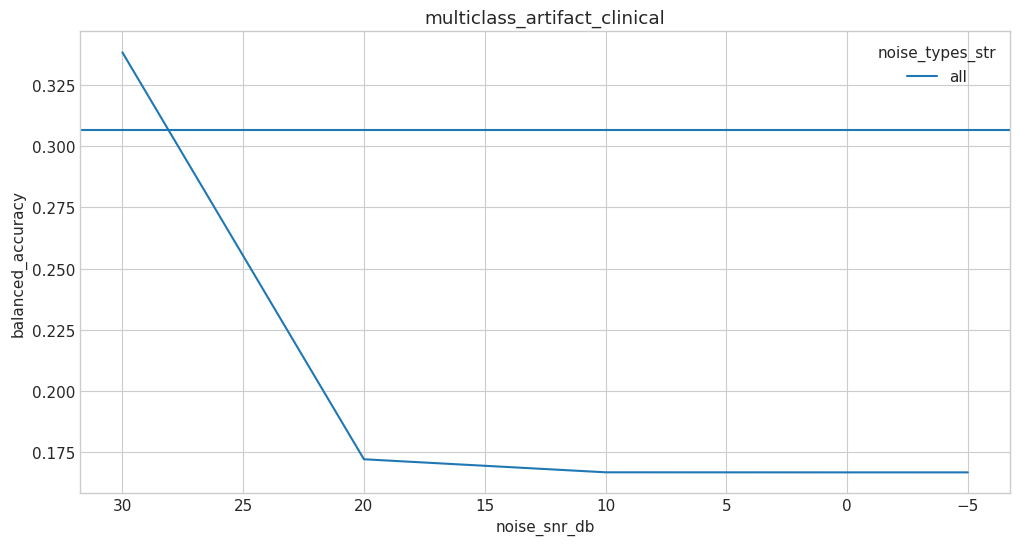

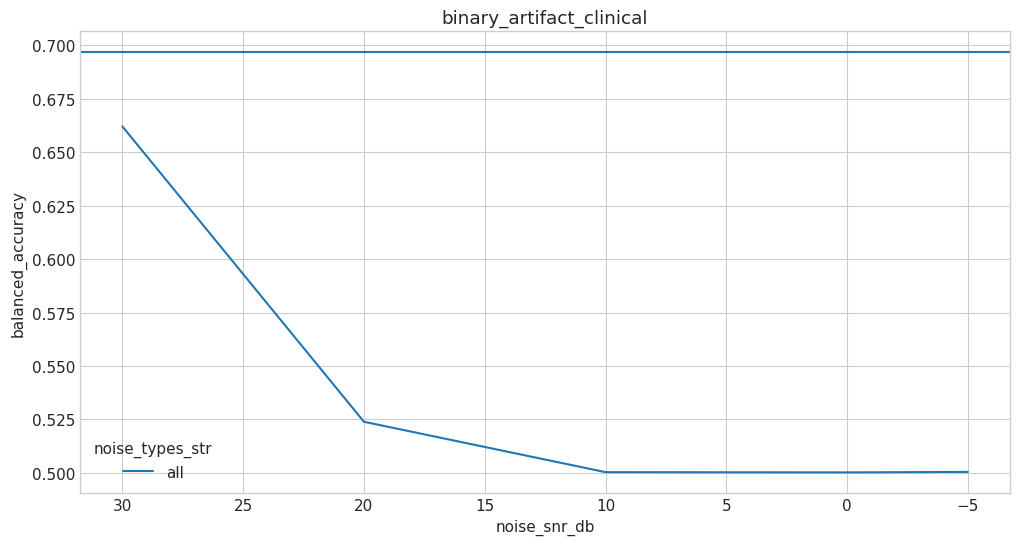

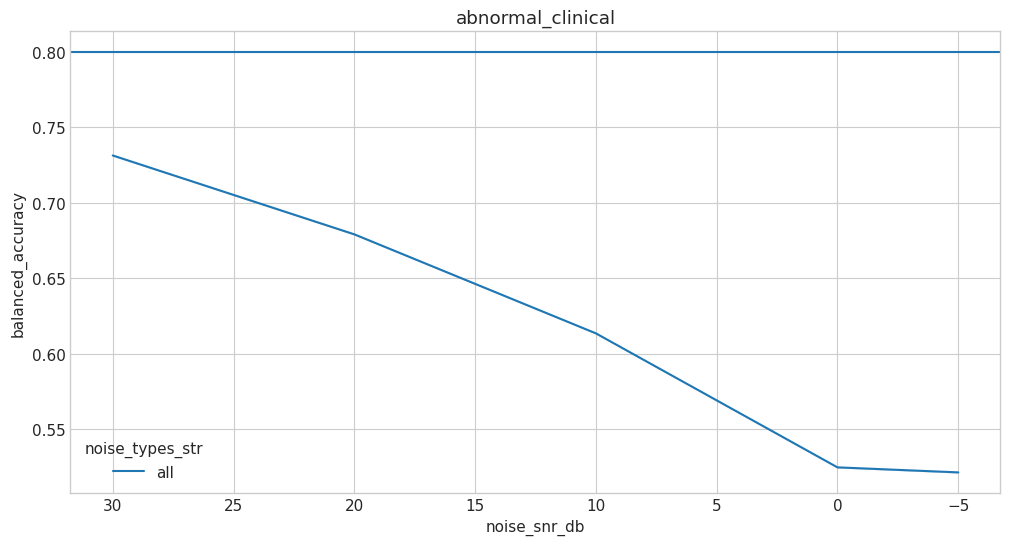

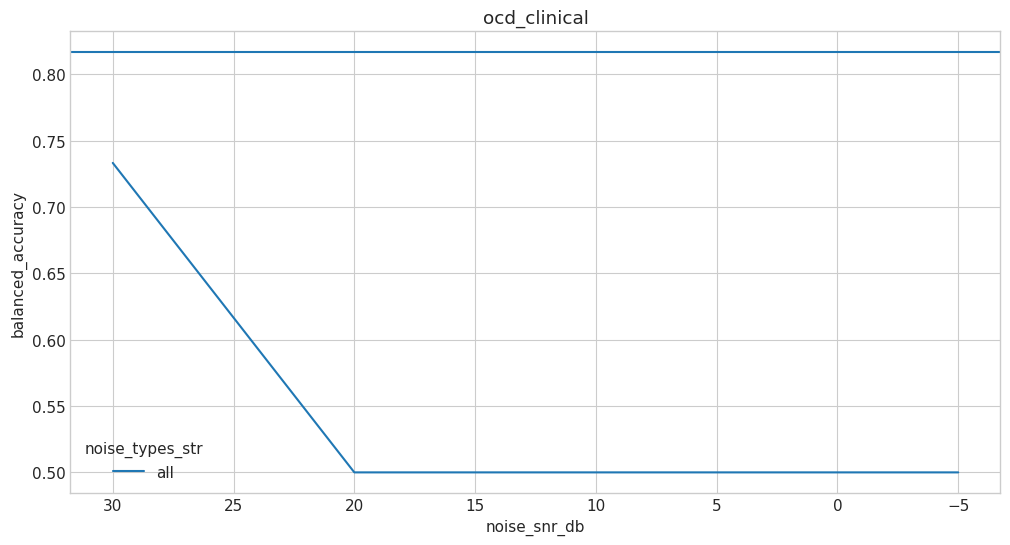

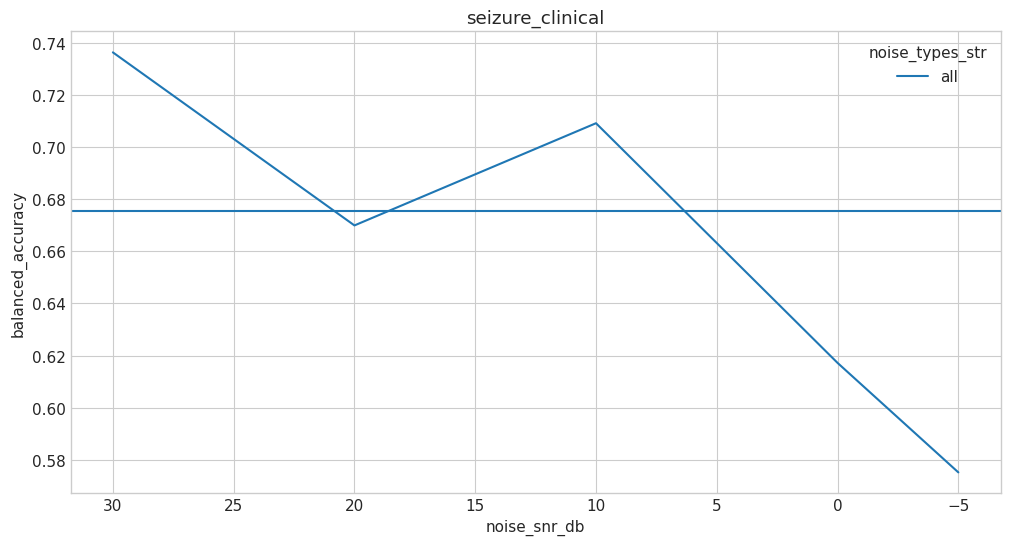

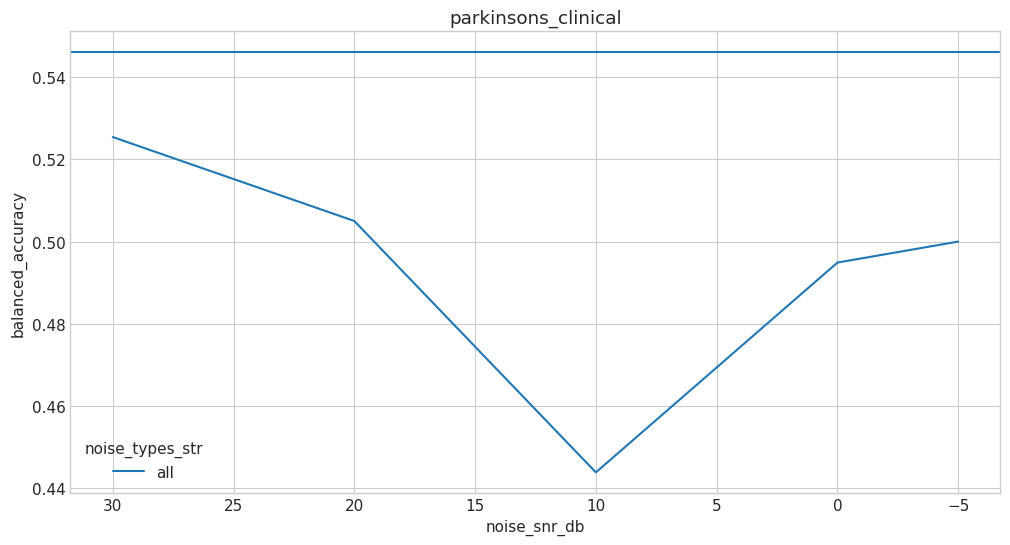

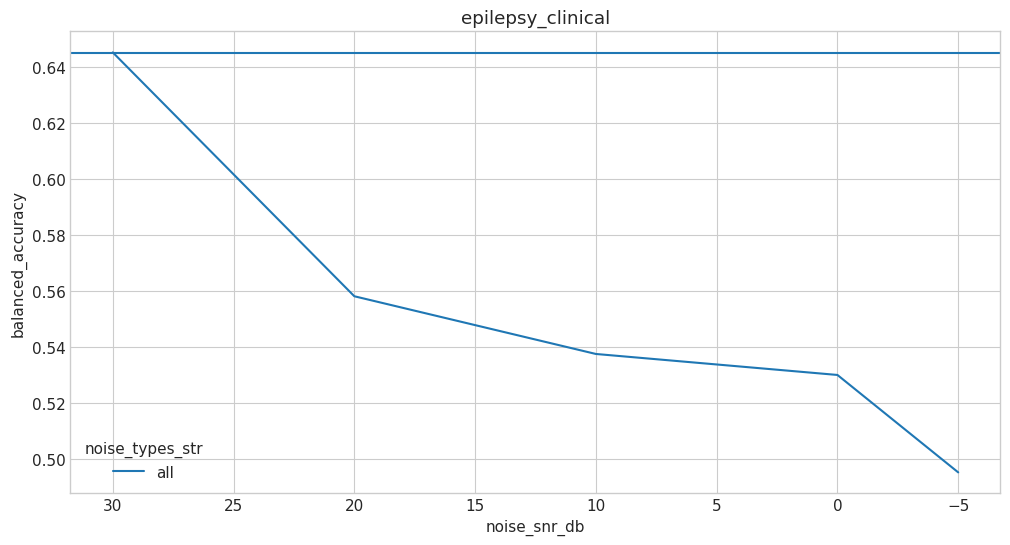

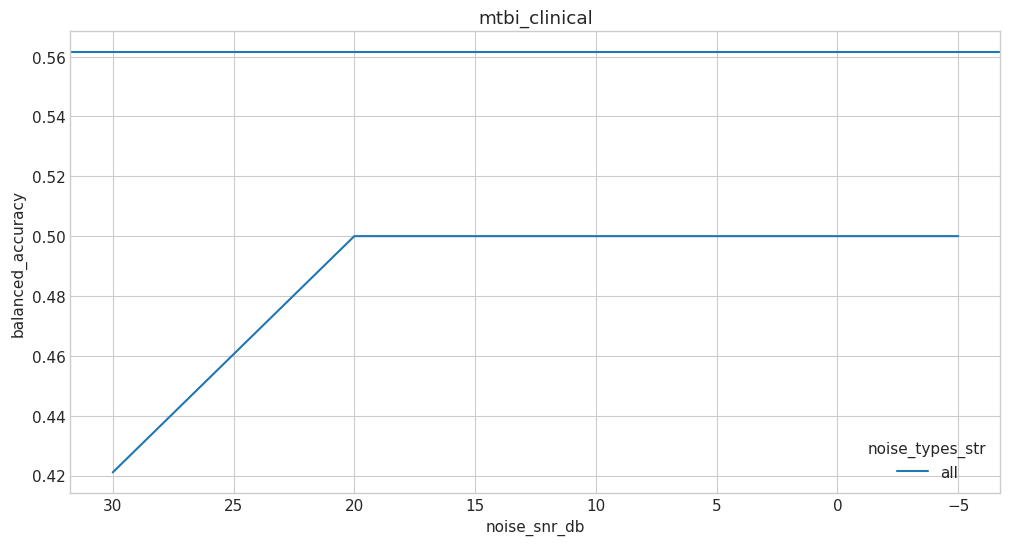

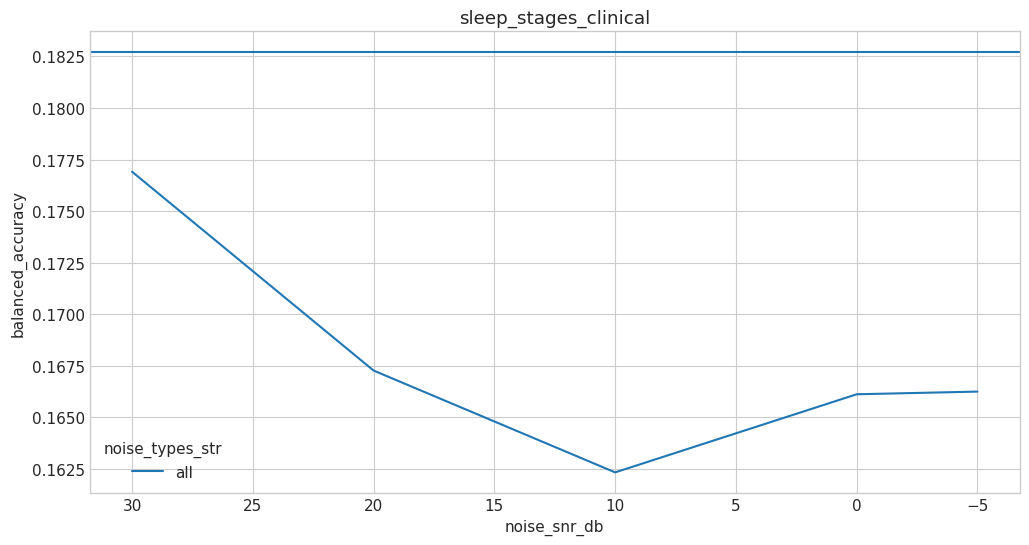

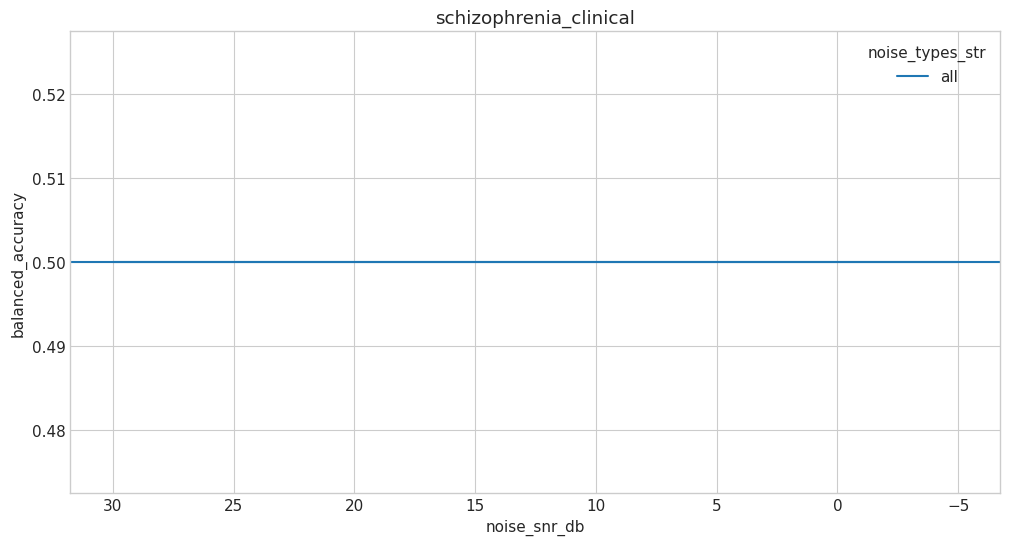

In [74]:
for task in df_all['task'].unique():


    df_for_noiseplot = df_all[(df_all["task"] == task) & (df_all["percentage"] == 1.0)]

    clean_baseline = df_for_noiseplot[df_for_noiseplot["is_clean"]].groupby("model_display")["balanced_accuracy"].mean()
    noise_to_plot  = df_for_noiseplot[~df_for_noiseplot["is_clean"]].sort_values("noise_snr_db", ascending=False)
    if noise_to_plot.empty:
        continue
    # break
    noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].replace('gaussian+one_over_f+emg+channel_dropout', 'all')
    plt.figure()
    sns.lineplot(data=noise_to_plot[noise_to_plot['noise_types_str'] == 'all'], x='noise_snr_db', y='balanced_accuracy', hue='noise_types_str',markers=True, dashes=False)
    plt.axhline(clean_baseline.iloc[0], label = 'no noise baseline')
    plt.gca().invert_xaxis()  # Higher noise to the right visually (optional)
    plt.title(task)


In [75]:
df_all.to_csv('results/labram_results_all.csv', index=False)